# Telco Customer Churn: Exploratory Data Analysis (EDA)

**Objective:** Understand the dataset, identify patterns, and uncover initial insights about customer churn.

**Dataset Source:** IBM Telco Customer Churn Dataset
**Rows:** 7,043
**Columns:** 21

In [1]:
# Data manipulation and analysis
import pandas as pd
import numpy as np

# Data visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Set visual style
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("Set2")

# Display all columns
pd.set_option('display.max_columns', None)

# Load the data
df = pd.read_csv('../data/raw/telco_churn.csv')  # The path to raw dataset

print(f"Dataset shape: {df.shape}")
print(f"Memory usage: {df.memory_usage(deep=True).sum() / 1024**2:.2f} MB")

Dataset shape: (7043, 21)
Memory usage: 6.82 MB


Get to Know the Data

In [ ]:
# 1. First 5 rows
df.head()

In [ ]:
#2. Column names and data types
df.info()

In [ ]:
# 3. Check for missing values
df.isnull().sum()

In [ ]:
# 4. Unique values in each column
for col in df.columns:
    print(f"{col}: {df[col].nunique()} unique values")
    print(df[col].unique()[:5])  # Show first 5 unique values   
    print("---")   

## 🔧 Data Cleaning: Converting TotalCharges to Numeric

**Issue:** The `TotalCharges` column was stored as a string, preventing numerical analysis.
**Cause:** Some values were empty or contained whitespace.
**Solution:** Used `pd.to_numeric(df['TotalCharges'], errors='coerce')` to convert, then filled missing values with the median.
**Result:** All 7,043 rows now have numeric TotalCharges values.


In [ ]:
# Convert to a number. errors='coerce' turns anything that can't be a number into a 'NaN' (Not a Number).
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

# Check how many 'NaN's we created
print(f"Missing values after conversion: {df['TotalCharges'].isnull().sum()}")

# Fill those 'NaN's with the median (the middle value)
median_charges = df['TotalCharges'].median()
df['TotalCharges'] = df['TotalCharges'].fillna(median_charges)

11


What we know about "Churn", Our target variable
Let's find some patterns

Churn Distribution:
Churn
No     5174
Yes    1869
Name: count, dtype: int64

Churn Rate: 26.54%


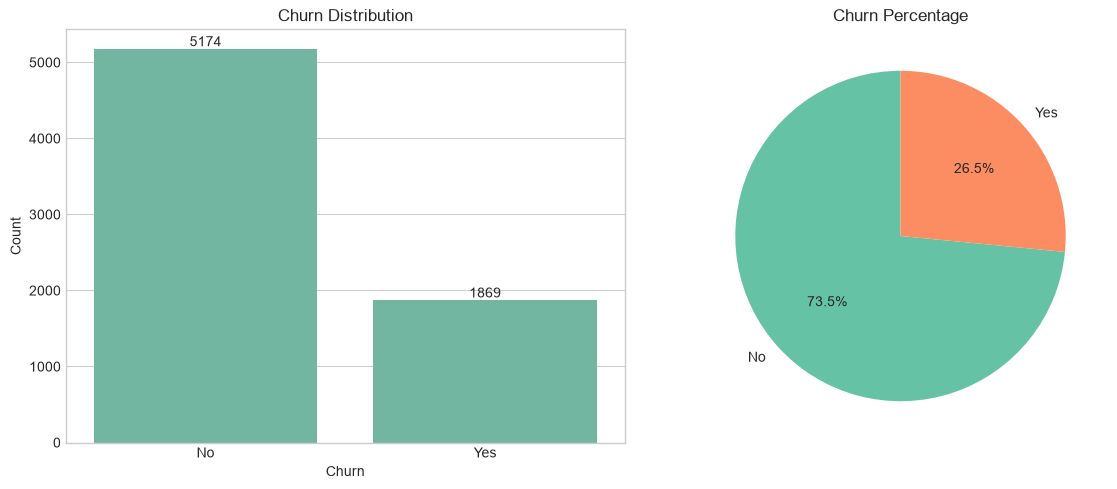

In [11]:
# Check churn distribution
churn_counts = df['Churn'].value_counts()
churn_percent = df['Churn'].value_counts(normalize=True) * 100

print("Churn Distribution:")
print(churn_counts)
print(f"\nChurn Rate: {churn_percent['Yes']:.2f}%")

# Visualize
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Count plot
sns.countplot(data=df, x='Churn', ax=axes[0])
axes[0].set_title('Churn Distribution')
axes[0].set_ylabel('Count')
axes[0].set_xlabel('Churn')
axes[0].bar_label(axes[0].containers[0])

# Pie chart
axes[1].pie(churn_counts, labels=churn_counts.index, autopct='%1.1f%%', startangle=90)
axes[1].set_title('Churn Percentage')

plt.tight_layout()
plt.savefig('../reports/figures/churn_distribution.png', dpi=300, bbox_inches='tight')
plt.show()

Analyse Numerical Features
How numerical features relate to churn

In [ ]:
# Numerical columns
num_cols = ['tenure', 'MonthlyCharges', 'TotalCharges']


# Create a function to plot distributions
def plot_numerical_features(df, num_cols):
    fig, axes = plt.subplots(2, 3, figsize=(15, 10))
    
    for i, col in enumerate(num_cols):
        # Distribution histogram
        row, col_idx = i // 3, i % 3
        sns.histplot(data=df, x=col, hue='Churn', kde=True, ax=axes[row, col_idx])
        axes[row, col_idx].set_title(f'Distribution of {col}')
        
        # Box plot for churn comparison
        row2, col_idx2 = (i + 3) // 3, (i + 3) % 3
        sns.boxplot(data=df, x='Churn', y=col, ax=axes[row2, col_idx2])
        axes[row2, col_idx2].set_title(f'{col} by Churn')
    
    plt.tight_layout()
    plt.savefig('../reports/figures/numerical_features.png', dpi=300, bbox_inches='tight')
    plt.show()

plot_numerical_features(df, num_cols)

What is the average tenure(/MonthlyCharges/TotalCharges) for a customer who churns vs. one who stays?

In [ ]:
# Statistical comparison of numerical features by churn
df.groupby('Churn')[num_cols].agg(['mean', 'median', 'std'])

Analyze Categorical Features

In [ ]:
# Identify categorical columns (excluding the target)
cat_cols = df.select_dtypes(include=['object']).columns.tolist()
cat_cols.remove('Churn')  # Remove target

print(f"Categorical columns: {cat_cols}")
print(f"Total categorical columns: {len(cat_cols)}")

# Calculate number of rows needed for subplots (3 columns per row)
n_cols = 3
n_rows = (len(cat_cols) + n_cols - 1) // n_cols  # Ceiling division

# Create subplots with dynamic sizing
fig, axes = plt.subplots(n_rows, n_cols, figsize=(20, 5 * n_rows))
axes = axes.flatten() if n_rows > 1 else [axes]  # Handle single row case

# Plot churn rate by each categorical feature
for i, col in enumerate(cat_cols):
    churn_rate = df.groupby(col)['Churn'].apply(lambda x: (x == 'Yes').mean() * 100).sort_values(ascending=False)
    churn_rate.plot(kind='bar', ax=axes[i], color='skyblue', edgecolor='black')
    axes[i].set_title(f'Churn Rate by {col}', fontsize=12)
    axes[i].set_ylabel('Churn Rate (%)')
    axes[i].set_xlabel('')
    axes[i].tick_params(axis='x', rotation=45)
    
    # Add value labels on bars
    for j, v in enumerate(churn_rate):
        axes[i].text(j, v + 1, f'{v:.1f}%', ha='center', fontsize=8)

# Hide any unused subplots
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.savefig('../reports/figures/categorical_churn_rates.png', dpi=300, bbox_inches='tight')
plt.show()

In [16]:
# Key insight: Contract type vs churn
contract_churn = df.groupby('Contract')['Churn'].apply(lambda x: (x == 'Yes').mean() * 100)
print("Churn Rate by Contract Type:")
print(contract_churn)

Churn Rate by Contract Type:
Contract
Month-to-month    42.709677
One year          11.269518
Two year           2.831858
Name: Churn, dtype: float64


## 📌 Key Observations

### 1. Data Overview
- The dataset has 7,043 rows and 21 columns.
- The target variable 'Churn' is imbalanced with ~26.5% churn rate.
- No immediate missing values are visible in most columns.

### 2. Data Quality Issues
- `TotalCharges` is stored as a string/object, needs conversion to numeric.
- Some columns like `SeniorCitizen` are stored as integers (0/1) but should be categorical.

### 3. Customer Demographics
- **Contract Type:** Month-to-month contracts have the highest churn rate (~42%), while those with 1-year contracts churn at ~12% and 2-year contracts at ~2.8%.
- **No Online Security:** Customers without online security churn at ~41% vs ~17% with it.
- **Payment Method:** Electronic check users churn the most (~45%), while those using bank transfer or credit card churn less (~16-17%).

### 4. Numerical Relationships
- **Tenure:** The longer a customer stays, the less likely they are to churn. Newer customers (0-12 months) are at highest risk.
- **Monthly Charges:** Customers with higher monthly charges (e.g., $80+) tend to churn more.
- **Total Charges:** Lower total charges (meaning newer customers) correlate with higher churn.

### 5. Initial Hypothesis
- Customers on short-term contracts with high monthly charges and no additional services (like online security) are prime churn candidates.
- The company should focus retention efforts on month-to-month customers in their first year.

Save your processed Data

In [18]:
# Save cleaned data
df.to_csv('../data/processed/telco_churn_cleaned.csv', index=False)
print("Cleaned data saved to data/processed/telco_churn_cleaned.csv")

Cleaned data saved to data/processed/telco_churn_cleaned.csv
